# Notebook 2 -- Logistic Regression

**Mục tiêu:**
- Triển khai Logistic Regression làm baseline
- Đánh giá bằng Accuracy, Precision, Recall, F1-score và lưu `y_prob` vào `../features/lr_y_prob.npy`


## 1. Import thư viện

In [1]:
import json
import numpy as np
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath('..'))
from credit_utils.utils import (
    load_creditcard_csv,
    preprocess_credit_card_data,
    apply_smote,
    select_threshold_from_pr_curve,
)

SEED = 42
np.random.seed(SEED)


## 2. Preprocessing

In [2]:
df = load_creditcard_csv()
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_credit_card_data(df)


1. Tách Features (X) và Target (y)...
2. Chia tập Train+Val / Test (80/20) với Stratify...
3. Chia tập Train / Val (70/10) với Stratify...
4. Áp dụng RobustScaler cho Time và Amount (fit trên train)...

Kích thước các tập:
  Train : (199364, 30) | Fraud rate: 0.173%
  Val   : (28481, 30)   | Fraud rate: 0.172%
  Test  : (56962, 30)  | Fraud rate: 0.172%


## 3. Training Và Validation Selection

Quy trình chọn model:
- Tách một validation set từ train set
- Train 2 nhánh LR: `class_weight='balanced'` và `SMOTE`
- So sánh nhánh bằng **validation PR-AUC** làm tiêu chí chính
- Chọn threshold từ `precision_recall_curve`
- Chỉ giữ threshold nếu có điểm nào thỏa `precision >= min_precision`; nếu không thì trả về `no_feasible_threshold`

In [3]:
VAL_SIZE = 0.2
MIN_PRECISION = 0.6
C_VALUES = [0.01, 0.10, 1, 10]
BRANCHES = ['balanced', 'smote']
MAX_ITER = 3000
TOL = 1e-3
FORCE_RETRAIN = False

ARTIFACT_DIR = Path('../features')
MODEL_DIR = Path('../models')
LR_MODEL_PATH = MODEL_DIR / 'fraud_lr_best.joblib'
LR_META_PATH = MODEL_DIR / 'fraud_lr_meta.json'
LR_Y_PROB_PATH = ARTIFACT_DIR / 'lr_y_prob.npy'
LR_VALIDATION_SUMMARY_PATH = ARTIFACT_DIR / 'lr_validation_summary.csv'

LR_CACHE_SIGNATURE = {
    'c_values': C_VALUES,
    'branches': BRANCHES,
    'min_precision': MIN_PRECISION,
    'max_iter': MAX_ITER,
    'tol': TOL,
}


In [4]:
def fit_branch(branch_name, c_value, X_train_base, y_train_base, X_val, y_val):
    if branch_name == 'balanced':
        model = LogisticRegression(
            solver='saga',
            class_weight='balanced',
            C=c_value,
            max_iter=MAX_ITER,
            tol=TOL,
            random_state=SEED,
        )
        X_fit, y_fit = X_train_base, y_train_base
        display_name = f'LR + class_weight=balanced | C={c_value}'
    elif branch_name == 'smote':
        model = LogisticRegression(
            solver='saga',
            C=c_value,
            max_iter=MAX_ITER,
            tol=TOL,
            random_state=SEED, 
        )
        X_fit, y_fit = apply_smote(X_train_base, y_train_base)
        display_name = f'LR + SMOTE | C={c_value}'
    else:
        raise ValueError(f'Unsupported branch: {branch_name}')

    model.fit(X_fit, y_fit)
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold_info = select_threshold_from_pr_curve(y_val, val_prob, min_precision=MIN_PRECISION)

    return {
        'branch_name': branch_name,
        'C': c_value,
        'display_name': display_name,
        'model': model,
        'X_fit_shape': X_fit.shape,
        'val_prob': val_prob,
        'val_pr_auc': float(average_precision_score(y_val, val_prob)),
        'val_roc_auc': float(roc_auc_score(y_val, val_prob)),
        'threshold_info': threshold_info,
    }


In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def _to_serializable(obj):
    if isinstance(obj, dict):
        return {key: _to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(value) for value in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        value = obj.item()
        return None if isinstance(value, float) and np.isnan(value) else value
    if isinstance(obj, float) and np.isnan(obj):
        return None
    return obj


cached_meta = None
used_lr_cache = False
if LR_META_PATH.exists():
    cached_meta = json.loads(LR_META_PATH.read_text(encoding='utf-8'))
    used_lr_cache = (
        not FORCE_RETRAIN
        and cached_meta.get('cache_signature') == LR_CACHE_SIGNATURE
        and LR_MODEL_PATH.exists()
        and LR_VALIDATION_SUMMARY_PATH.exists()
    )

if used_lr_cache:
    print('Loading cached Logistic Regression artifacts...')
    winner = cached_meta['winner']
    winner_model = joblib.load(LR_MODEL_PATH)
    validation_summary = pd.read_csv(LR_VALIDATION_SUMMARY_PATH)
else:
    experiment_results = []
    for branch_name in BRANCHES:
        for c_value in C_VALUES:
            result = fit_branch(branch_name, c_value, X_train, y_train, X_val, y_val)
            experiment_results.append(result)

    validation_rows = []
    for result in experiment_results:
        threshold_info = result['threshold_info']
        validation_rows.append({
            'Branch': result['branch_name'],
            'C': result['C'],
            'Model': result['display_name'],
            'Train shape': str(result['X_fit_shape']),
            'Val shape': str(X_val.shape),
            'Val PR-AUC': result['val_pr_auc'],
            'Val ROC-AUC': result['val_roc_auc'],
            'Threshold': threshold_info['threshold'],
            'Val Precision': threshold_info['precision'],
            'Val Recall': threshold_info['recall'],
            'Val F1': threshold_info['f1'],
            'Threshold Status': threshold_info['selection_note'],
            'Feasible Thresholds': threshold_info['num_feasible_thresholds'],
        })

    validation_summary = pd.DataFrame(validation_rows)

    feasible_results = [
        result for result in experiment_results
        if result['threshold_info']['selection_note'] == 'feasible_threshold'
    ]

    candidate_results = feasible_results if feasible_results else experiment_results
    winner = max(
        candidate_results,
        key=lambda result: (
            result['val_pr_auc'],
            np.nan_to_num(result['threshold_info']['recall'], nan=-1.0),
            np.nan_to_num(result['threshold_info']['f1'], nan=-1.0),
        ),
    )
    winner_model = winner['model']

    validation_summary.to_csv(LR_VALIDATION_SUMMARY_PATH, index=False)
    joblib.dump(winner_model, LR_MODEL_PATH)

    winner_to_save = {
        key: value for key, value in winner.items()
        if key not in {'model', 'val_prob'}
    }
    LR_META_PATH.write_text(
        json.dumps(
            {
                'cache_signature': LR_CACHE_SIGNATURE,
                'winner': _to_serializable(winner_to_save),
            },
            indent=2,
        ),
        encoding='utf-8',
    )
    print(f'Saved validation summary: {LR_VALIDATION_SUMMARY_PATH}')
    print(f'Saved model cache: {LR_MODEL_PATH}')
    print(f'Saved metadata: {LR_META_PATH}\n')

winner_threshold_info = winner['threshold_info']

print(f'MIN_PRECISION used for threshold selection: {MIN_PRECISION:.2f}')
print(f'C_VALUES tested: {C_VALUES}')
print(f'BRANCHES tested: {BRANCHES}\n')
print(validation_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nSelected winner by validation metrics:')
print(f"- Winner branch: {winner['display_name']}")
print(f"- Branch type: {winner['branch_name']}")
print(f"- Best C: {winner['C']}")
print(f"- Validation PR-AUC: {winner['val_pr_auc']:.4f}")
print(f"- Threshold status: {winner_threshold_info['selection_note']}")
if winner_threshold_info['threshold'] is not None:
    print(f"- Selected threshold: {winner_threshold_info['threshold']:.4f}")
else:
    print('- No feasible threshold satisfied the current MIN_PRECISION.')


Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%
Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%
Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%
Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%
Saved validation summary: ..\features\lr_validation_summary.csv
Saved model cache: ..\models\fraud_lr_best.joblib
Saved metadata: ..\models\fraud_lr_meta.json
MIN_PRECISION used for threshold selection: 0.60
C_VALUES tested: [0.01, 0.1, 1, 10]
BRANCHES tested: ['balanced', 'smote']
  Branch       C                               Model  Train shape   Val shape  Val PR-AUC  Val ROC-AUC  Threshold  Val Precision  Val Recall  Val F1   Threshold Status  Feasible Thresholds
balanced  0.0100 LR + class_weight=balanced | C=0.01 (199364, 30) (28481, 30)      0.6125       0.9613     0.9992         0.7255      0.7551  0.7400 feasible_threshold                   50
balanced  0.1000  LR + class_weight=balanced | C=0.1 (199364, 30) (28481, 30)      0.6153       0.9613     0.9994         0.7115   

## 4. Test Output

Nhánh thắng được chọn hoàn toàn bằng validation.  
Chỉ nhánh này mới được mang sang test set để đánh giá cuối và xuất `lr_y_prob.npy`.

In [10]:
winner_threshold_info = winner['threshold_info']

if used_lr_cache and LR_Y_PROB_PATH.exists():
    lr_y_prob = np.load(LR_Y_PROB_PATH)
    print(f'Loaded cached probabilities: {LR_Y_PROB_PATH}')
else:
    lr_y_prob = winner_model.predict_proba(X_test)[:, 1]
    np.save(LR_Y_PROB_PATH, lr_y_prob)
    print(f'Saved: {LR_Y_PROB_PATH}')

if winner_threshold_info['threshold'] is not None:
    lr_y_pred = (lr_y_prob >= winner_threshold_info['threshold']).astype(int)
    print(f"Winner threshold applied on test: {winner_threshold_info['threshold']:.4f}")
    print(f"Positive predictions on test: {int(lr_y_pred.sum())}")
else:
    lr_y_pred = None
    print('No feasible threshold found on validation, so threshold-based test metrics will be skipped.')

print(f'lr_y_prob shape: {lr_y_prob.shape}')


Saved: ..\features\lr_y_prob.npy
Winner threshold applied on test: 0.9994
Positive predictions on test: 124
lr_y_prob shape: (56962,)


## 5. Metrics

In [11]:
test_metrics = {
    'Model': winner['display_name'],
    'Branch': winner['branch_name'],
    'C': winner['C'],
    'Validation PR-AUC': winner['val_pr_auc'],
    'Validation ROC-AUC': winner['val_roc_auc'],
    'Threshold Status': winner_threshold_info['selection_note'],
    'Threshold': winner_threshold_info['threshold'],
    'Test ROC-AUC': roc_auc_score(y_test, lr_y_prob),
    'Test PR-AUC': average_precision_score(y_test, lr_y_prob),
}

if lr_y_pred is not None:
    cm = confusion_matrix(y_test, lr_y_pred)
    test_metrics.update({
        'Accuracy': accuracy_score(y_test, lr_y_pred),
        'Precision': precision_score(y_test, lr_y_pred, zero_division=0),
        'Recall': recall_score(y_test, lr_y_pred, zero_division=0),
        'F1-score': f1_score(y_test, lr_y_pred, zero_division=0),
        'TP': int(cm[1, 1]),
        'FP': int(cm[0, 1]),
        'TN': int(cm[0, 0]),
        'FN': int(cm[1, 0]),
    })

test_metrics_df = pd.DataFrame([test_metrics])
print(test_metrics_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

if lr_y_pred is not None:
    print('\nClassification Report - Selected LR branch')
    print(classification_report(y_test, lr_y_pred, target_names=['Non-Fraud', 'Fraud'], zero_division=0))

    print('Confusion Matrix - Selected LR branch')
    print(pd.DataFrame(
        confusion_matrix(y_test, lr_y_pred),
        index=['Actual 0', 'Actual 1'],
        columns=['Pred 0', 'Pred 1'],
    ))
else:
    print('\nThreshold-based test metrics were skipped because validation did not find a feasible threshold.')

                           Model   Branch  C  Validation PR-AUC  Validation ROC-AUC   Threshold Status  Threshold  Test ROC-AUC  Test PR-AUC  Accuracy  Precision  Recall  F1-score  TP  FP    TN  FN
LR + class_weight=balanced | C=1 balanced  1             0.6216              0.9614 feasible_threshold     0.9994        0.9740       0.7170    0.9990     0.6694  0.8469    0.7477  83  41 56823  15

Classification Report - Selected LR branch
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.67      0.85      0.75        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix - Selected LR branch
          Pred 0  Pred 1
Actual 0   56823      41
Actual 1      15      83


## 6. Visualization

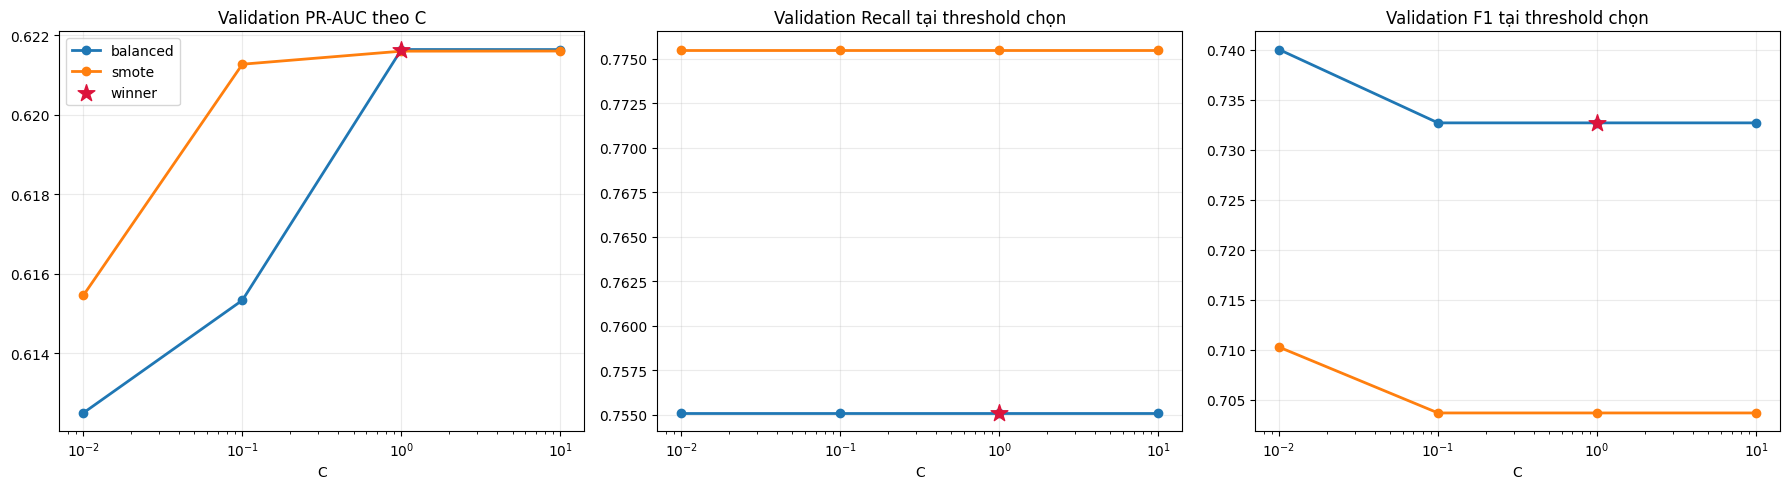

In [12]:
plot_df = validation_summary.copy().sort_values(['Branch', 'C'])
branch_colors = {
    'balanced': '#1f77b4',
    'smote': '#ff7f0e',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_names = ['Val PR-AUC', 'Val Recall', 'Val F1']
metric_titles = [
    'Validation PR-AUC theo C',
    'Validation Recall tại threshold chọn',
    'Validation F1 tại threshold chọn',
]

for ax, metric, title in zip(axes, metric_names, metric_titles):
    for branch_name, branch_df in plot_df.groupby('Branch'):
        branch_df = branch_df.sort_values('C')
        ax.plot(
            branch_df['C'],
            branch_df[metric],
            marker='o',
            linewidth=2,
            color=branch_colors.get(branch_name, '#333333'),
            label=branch_name,
        )

    winner_row = plot_df[
        (plot_df['Branch'] == winner['branch_name']) & (plot_df['C'] == winner['C'])
    ].iloc[0]
    ax.scatter(
        [winner_row['C']],
        [winner_row[metric]],
        s=160,
        marker='*',
        color='crimson',
        zorder=5,
        label='winner' if metric == 'Val PR-AUC' else None,
    )
    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel('C')
    ax.grid(alpha=0.25)

axes[0].legend()
plt.tight_layout()
plt.show()


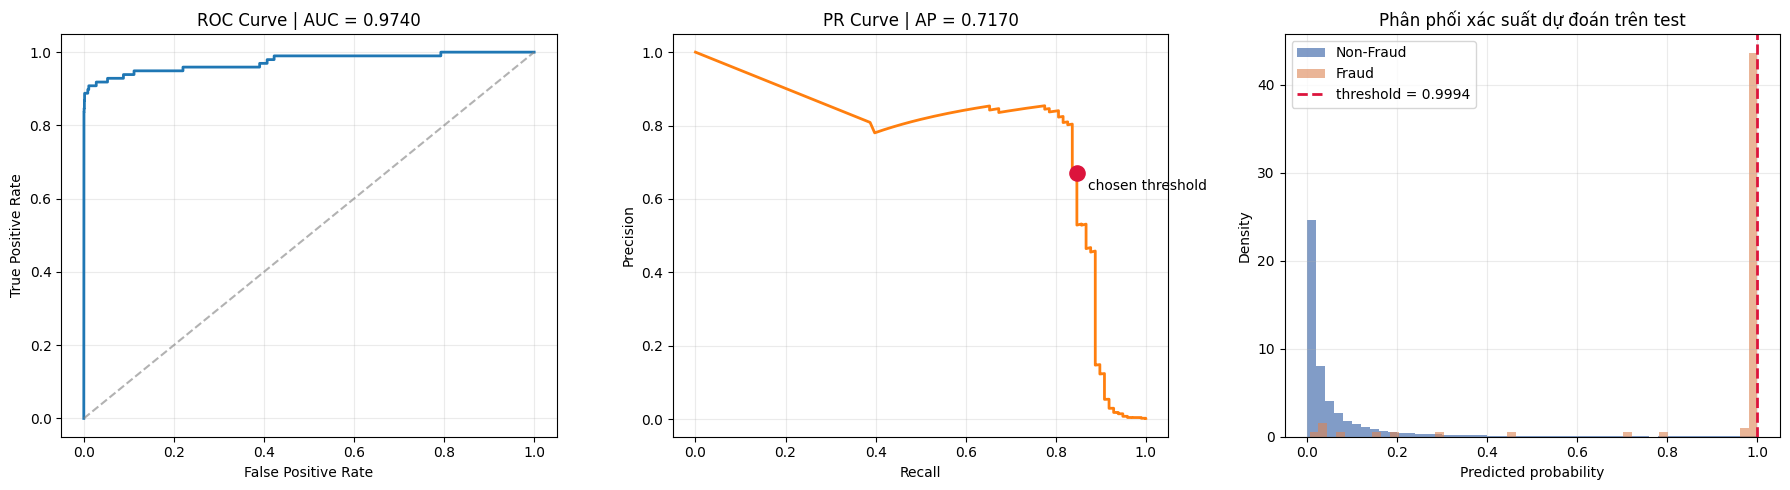

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, lr_y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, lr_y_prob)

axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
axes[0].set_title(f"ROC Curve | AUC = {roc_auc_score(y_test, lr_y_prob):.4f}")
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].grid(alpha=0.25)

axes[1].plot(recall_curve, precision_curve, color='#ff7f0e', linewidth=2)
axes[1].set_title(f"PR Curve | AP = {average_precision_score(y_test, lr_y_prob):.4f}")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].grid(alpha=0.25)

if lr_y_pred is not None:
    test_precision = precision_score(y_test, lr_y_pred, zero_division=0)
    test_recall = recall_score(y_test, lr_y_pred, zero_division=0)
    axes[1].scatter(test_recall, test_precision, color='crimson', s=120, zorder=5)
    axes[1].annotate('chosen threshold', (test_recall, test_precision), textcoords='offset points', xytext=(8, -12))

axes[2].hist(lr_y_prob[y_test == 0], bins=50, alpha=0.70, color='#4c72b0', density=True, label='Non-Fraud')
axes[2].hist(lr_y_prob[y_test == 1], bins=50, alpha=0.60, color='#dd8452', density=True, label='Fraud')
if winner_threshold_info['threshold'] is not None:
    axes[2].axvline(winner_threshold_info['threshold'], color='crimson', linestyle='--', linewidth=2, label=f"threshold = {winner_threshold_info['threshold']:.4f}")
axes[2].set_title('Phân phối xác suất dự đoán trên test')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
